In [ ]:
# Install packages if required
!pip -q install requests pandas numpy matplotlib statsmodels

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

START_YEAR = 2000
END_YEAR = 2024

COUNTRIES = {
    "IND": "India",
    "CHN": "China",
    "BRA": "Brazil",
    "ZAF": "South Africa",
    "USA": "United States",
    "DEU": "Germany"
}

# World Bank indicators
INDICATORS = {
    "SI.POV.GINI": "gini",
    "NY.GDP.MKTP.KD.ZG": "gdp_growth",
    "NY.GDP.PCAP.KD": "gdp_per_capita",
    "SI.POV.DDAY": "poverty_rate",
    "SP.POP.TOTL": "population"
}

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Countries:", COUNTRIES)
print("Period:", START_YEAR, "-", END_YEAR)

Countries: {'IND': 'India', 'CHN': 'China', 'BRA': 'Brazil', 'ZAF': 'South Africa', 'USA': 'United States', 'DEU': 'Germany'}
Period: 2000 - 2024


In [ ]:
indicator_description = pd.DataFrame({
    "variable": [
        "gini",
        "gdp_growth",
        "gdp_per_capita",
        "poverty_rate",
        "population"
    ],
    "meaning": [
        "Gini coefficient measuring income inequality",
        "Annual GDP growth rate (%)",
        "GDP per capita at constant prices",
        "Poverty headcount ratio at the selected World Bank poverty line",
        "Total population"
    ]
})

indicator_description

,variable,meaning
0,gini,Gini coefficient measuring income inequality
1,gdp_growth,Annual GDP growth rate (%)
2,gdp_per_capita,GDP per capita at constant prices
3,poverty_rate,Poverty headcount ratio at the selected World ...
4,population,Total population


In [ ]:
# ============================================================
# WORLD BANK API FUNCTION
# ============================================================

def get_world_bank_indicator(
    country_codes,
    indicator_code,
    start_year=2000,
    end_year=2024
):
    """
    Download one World Bank indicator for one or more countries.
    """

    url = (
        f"https://api.worldbank.org/v2/"
        f"country/{country_codes}/"
        f"indicator/{indicator_code}"
    )

    params = {
        "format": "json",
        "date": f"{start_year}:{end_year}",
        "per_page": 1000
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    result = response.json()

    # World Bank normally returns:
    # result[0] = metadata
    # result[1] = observations

    if len(result) < 2 or result[1] is None:
        return pd.DataFrame()

    records = []

    for observation in result[1]:

        records.append({
            "country_code": observation.get("countryiso3code"),
            "country": observation["country"]["value"],
            "year": int(observation["date"]),
            "value": observation.get("value")
        })

    return pd.DataFrame(records)

In [ ]:
test_data = get_world_bank_indicator(
    country_codes="IND",
    indicator_code="NY.GDP.PCAP.KD",
    start_year=START_YEAR,
    end_year=END_YEAR
)

test_data.head()


,country_code,country,year,value
0,IND,India,2024,"2,366.833"
1,IND,India,2023,"2,229.715"
2,IND,India,2022,"2,098.211"
3,IND,India,2021,"1,965.309"
4,IND,India,2020,"1,806.501"


In [ ]:
# ============================================================
# DOWNLOAD ALL INDICATORS
# ============================================================

country_codes = ";".join(COUNTRIES.keys())

all_indicator_data = []

for indicator_code, variable_name in INDICATORS.items():

    print(f"Downloading {indicator_code} → {variable_name}")

    temp = get_world_bank_indicator(
        country_codes=country_codes,
        indicator_code=indicator_code,
        start_year=START_YEAR,
        end_year=END_YEAR
    )

    if temp.empty:
        print(f"WARNING: No data returned for {indicator_code}")
        continue

    temp = temp.rename(
        columns={"value": variable_name}
    )

    all_indicator_data.append(temp)

print("Download complete.")

Download complete.


In [ ]:
# ============================================================
# MERGE INDICATORS
# ============================================================

data = all_indicator_data[0].copy()

for temp in all_indicator_data[1:]:

    data = data.merge(
        temp,
        on=["country_code", "country", "year"],
        how="outer"
    )

data = data.sort_values(
    ["country", "year"]
).reset_index(drop=True)

data.head(10)

,country_code,country,year,gini,gdp_growth,gdp_per_capita,poverty_rate,population
0,BRA,Brazil,2000,NaN,4.388,"6,817.784",NaN,174018282
1,BRA,Brazil,2001,58.400,1.390,"6,823.034",17.500,176301203
2,BRA,Brazil,2002,58.100,3.053,"6,944.623",16.200,178503484
3,BRA,Brazil,2003,57.600,1.141,"6,941.440",17.100,180622688
4,BRA,Brazil,2004,56.500,5.760,"7,258.782",15.300,182675143
5,BRA,Brazil,2005,56.300,3.202,"7,409.569",13.700,184688101
6,BRA,Brazil,2006,55.600,3.962,"7,622.040",11.400,186653106
7,BRA,Brazil,2007,54.900,6.070,"8,003.254",10.800,188552320
8,BRA,Brazil,2008,54.000,5.094,"8,330.765",9.100,190367302
9,BRA,Brazil,2009,53.700,-0.126,"8,246.097",8.400,192079951


In [ ]:
print("Shape:", data.shape)

print("\nCountries:")
print(data["country"].unique())

print("\nYear range:")
print(data["year"].min(), "to", data["year"].max())

print("\nColumns:")
print(data.columns.tolist())

Shape: (150, 8)

Countries:
['Brazil' 'China' 'Germany' 'India' 'South Africa' 'United States']

Year range:
2000 to 2024

Columns:
['country_code', 'country', 'year', 'gini', 'gdp_growth', 'gdp_per_capita', 'poverty_rate', 'population']


In [ ]:
country_coverage = (
    data
    .groupby("country")
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        observations=("year", "count")
    )
    .reset_index()
)

country_coverage

,country,first_year,last_year,observations
0,Brazil,2000,2024,25
1,China,2000,2024,25
2,Germany,2000,2024,25
3,India,2000,2024,25
4,South Africa,2000,2024,25
5,United States,2000,2024,25


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_percent": data.isna().mean() * 100
})

missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
gini,53,35.333
poverty_rate,53,35.333
country,0,0.000
country_code,0,0.000
year,0,0.000
gdp_growth,0,0.000
gdp_per_capita,0,0.000
population,0,0.000


In [ ]:
variables = [
    "gini",
    "gdp_growth",
    "gdp_per_capita",
    "poverty_rate",
    "population"
]

missing_by_country = (
    data
    .groupby("country")[variables]
    .apply(lambda x: x.isna().sum())
)

missing_by_country

,gini,gdp_growth,gdp_per_capita,poverty_rate,population
country,,,,,
Brazil,2,0,0,2,0
China,9,0,0,9,0
Germany,2,0,0,2,0
India,21,0,0,21,0
South Africa,19,0,0,19,0
United States,0,0,0,0,0


In [ ]:
# Check duplicate country-year combinations

duplicates = data.duplicated(
    subset=["country_code", "year"]
).sum()

print("Duplicate country-year rows:", duplicates)

Duplicate country-year rows: 0


In [ ]:
print("Negative GDP per capita:",
      (data["gdp_per_capita"] < 0).sum())

print("Negative population:",
      (data["population"] < 0).sum())

print("Gini outside 0-100:",
      ((data["gini"] < 0) | (data["gini"] > 100)).sum())

Negative GDP per capita: 0
Negative population: 0
Gini outside 0-100: 0


In [ ]:
# ============================================================
# ANALYSIS DATASETS
# ============================================================

# Inequality + growth + development
gini_df = data.dropna(
    subset=[
        "gini",
        "gdp_growth",
        "gdp_per_capita"
    ]
).copy()

# Poverty analysis
poverty_df = data.dropna(
    subset=[
        "poverty_rate",
        "gdp_growth",
        "gdp_per_capita"
    ]
).copy()

# Full dataset requiring every variable
full_df = data.dropna(
    subset=[
        "gini",
        "gdp_growth",
        "gdp_per_capita",
        "poverty_rate",
        "population"
    ]
).copy()

print("Original:", data.shape)
print("Gini analysis:", gini_df.shape)
print("Poverty analysis:", poverty_df.shape)
print("Full analysis:", full_df.shape)

Original: (150, 8)
Gini analysis: (97, 8)
Poverty analysis: (97, 8)
Full analysis: (97, 8)


In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

gini_df["log_gdp_per_capita"] = np.log(
    gini_df["gdp_per_capita"]
)

gini_df["log_gdp_per_capita_sq"] = (
    gini_df["log_gdp_per_capita"] ** 2
)

poverty_df["log_gdp_per_capita"] = np.log(
    poverty_df["gdp_per_capita"]
)

full_df["log_gdp_per_capita"] = np.log(
    full_df["gdp_per_capita"]
)

full_df["log_gdp_per_capita_sq"] = (
    full_df["log_gdp_per_capita"] ** 2
)

In [ ]:
descriptive_stats = (
    gini_df
    .groupby("country")
    [
        [
            "gini",
            "gdp_growth",
            "gdp_per_capita"
        ]
    ]
    .agg(["mean", "min", "max"])
)

descriptive_stats

gini               gdp_growth               gdp_per_capita  \
                mean    min    max       mean    min    max           mean   
country                                                                      
Brazil        53.809 48.800 58.400      2.070 -3.546  6.070      8,403.363   
China         39.675 35.700 43.700      7.564  2.340 11.454      7,789.955   
Germany       31.083 28.700 33.700      1.270 -5.545  4.135     39,786.431   
India         27.450 25.500 28.800      7.159  5.241  7.923      1,356.880   
South Africa  59.983 54.100 65.000      3.197  1.414  5.277      5,668.748   
United States 41.064 39.700 41.900      2.219 -2.577  6.152     55,875.308   

                                     
                     min        max  
country                              
Brazil         6,823.034  9,566.745  
China          2,610.663 11,830.299  
Germany       35,104.131 44,817.132  
India            892.597  2,098.211  
South Africa   4,700.876  6,155.006  
United States 48,597.425 66,856.513

In [ ]:
country_summary = (
    gini_df
    .groupby("country")
    .agg(
        average_gini=("gini", "mean"),
        average_growth=("gdp_growth", "mean"),
        average_gdp_per_capita=("gdp_per_capita", "mean"),
        latest_gini=("gini", "last"),
        latest_gdp_per_capita=("gdp_per_capita", "last")
    )
    .reset_index()
)

country_summary

,country,average_gini,average_growth,average_gdp_per_capita,latest_gini,latest_gdp_per_capita
0,Brazil,53.809,2.070,"8,403.363",50.300,"9,566.745"
1,China,39.675,7.564,"7,789.955",36.000,"11,830.299"
2,Germany,31.083,1.270,"39,786.431",33.700,"44,817.132"
3,India,27.450,7.159,"1,356.880",25.500,"2,098.211"
4,South Africa,59.983,3.197,"5,668.748",54.100,"5,786.865"
5,United States,41.064,2.219,"55,875.308",41.800,"66,856.513"


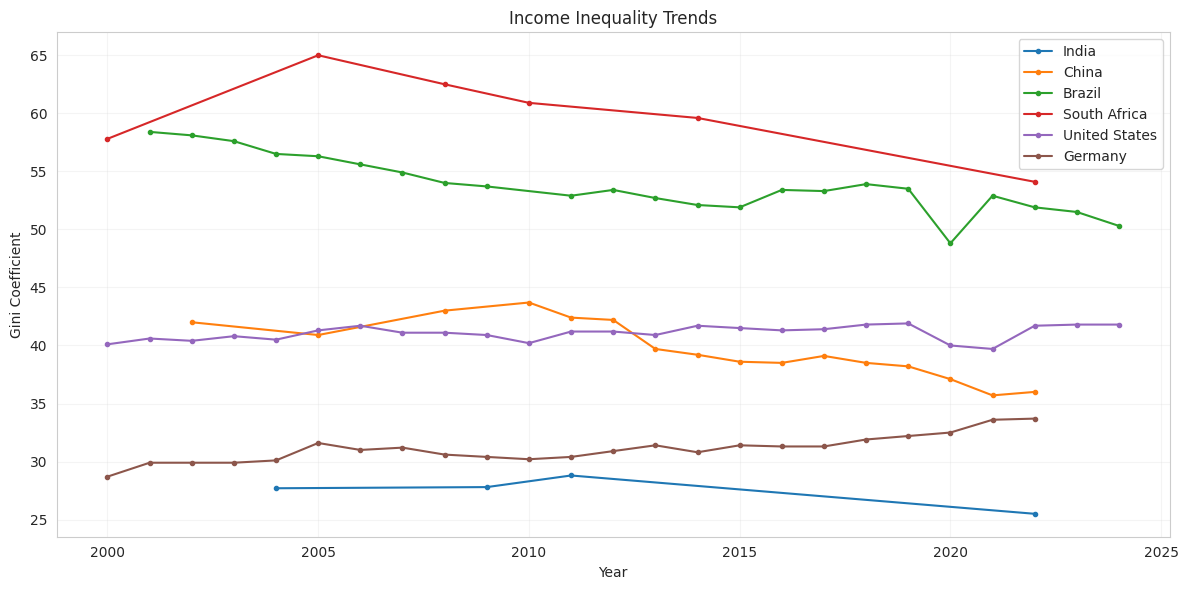

In [ ]:
plt.figure(figsize=(12, 6))

for country in COUNTRIES.values():

    temp = gini_df[
        gini_df["country"] == country
    ]

    plt.plot(
        temp["year"],
        temp["gini"],
        marker="o",
        markersize=3,
        label=country
    )

plt.title("Income Inequality Trends")
plt.xlabel("Year")
plt.ylabel("Gini Coefficient")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "gini_trends.png",
    dpi=300
)

plt.show()

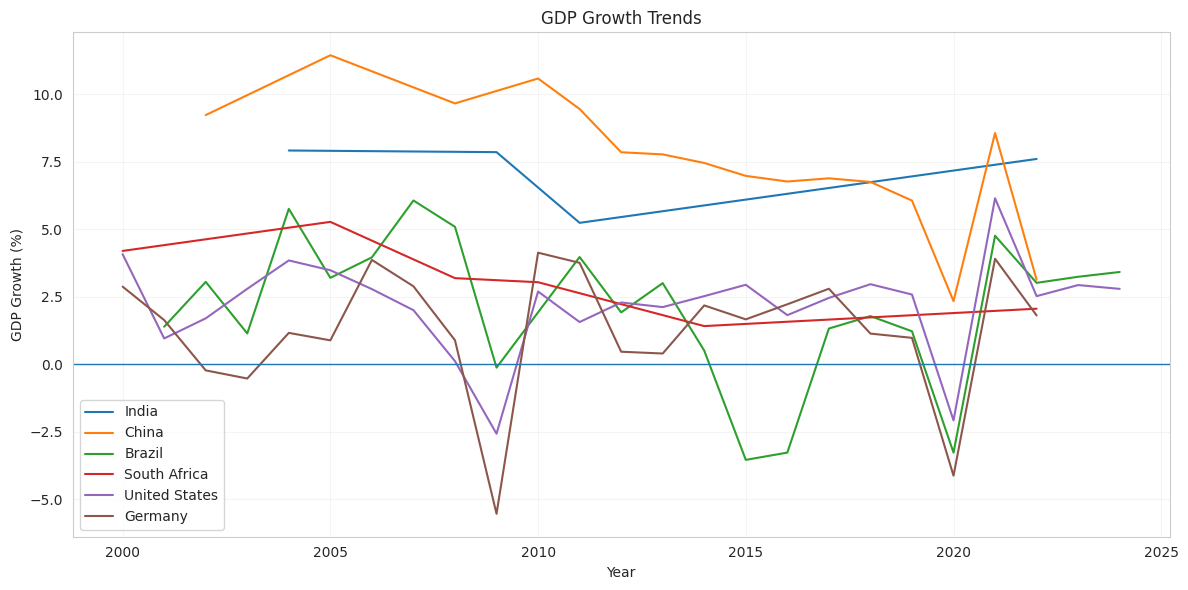

In [ ]:
plt.figure(figsize=(12, 6))

for country in COUNTRIES.values():

    temp = gini_df[
        gini_df["country"] == country
    ]

    plt.plot(
        temp["year"],
        temp["gdp_growth"],
        label=country
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("GDP Growth Trends")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "gdp_growth_trends.png",
    dpi=300
)

plt.show()

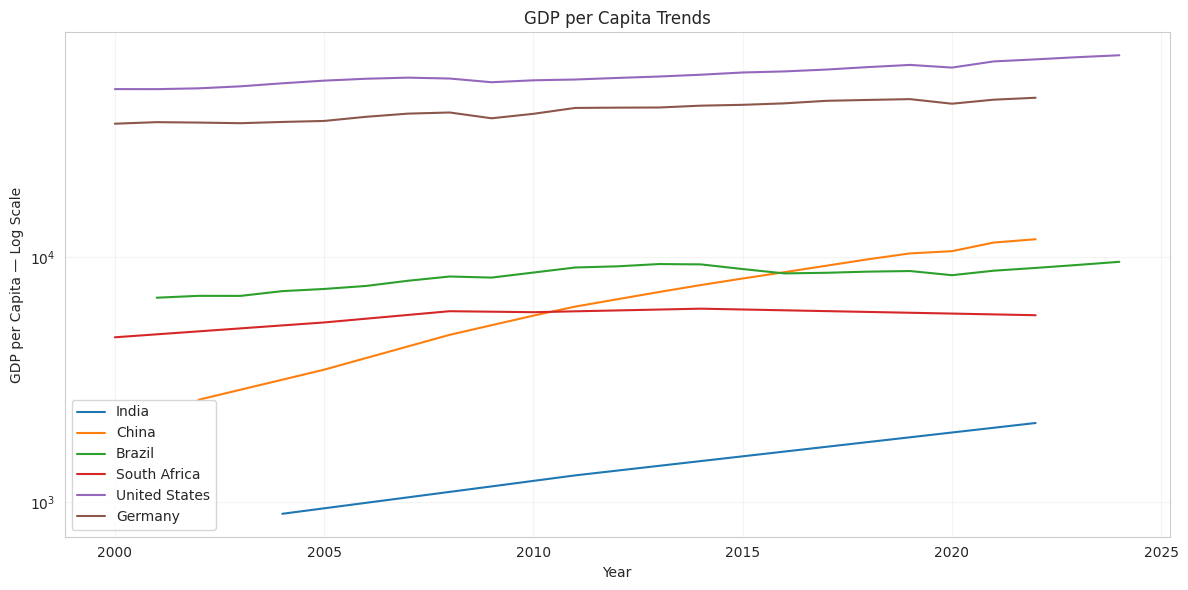

In [ ]:
plt.figure(figsize=(12, 6))

for country in COUNTRIES.values():

    temp = gini_df[
        gini_df["country"] == country
    ]

    plt.plot(
        temp["year"],
        temp["gdp_per_capita"],
        label=country
    )

plt.yscale("log")

plt.title("GDP per Capita Trends")
plt.xlabel("Year")
plt.ylabel("GDP per Capita — Log Scale")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "gdp_per_capita_trends.png",
    dpi=300
)

plt.show()

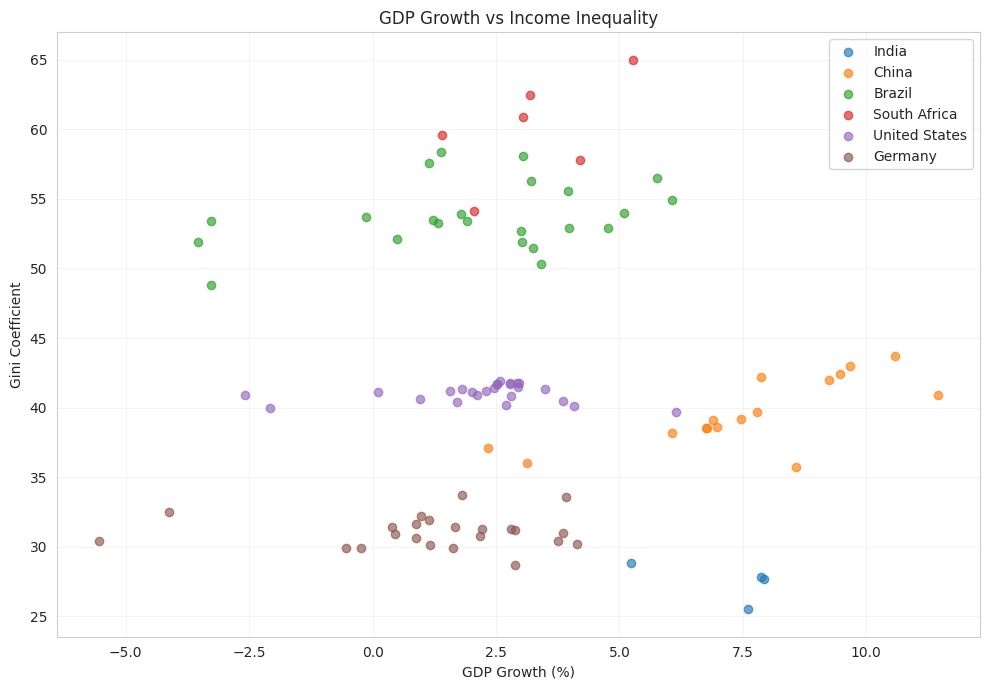

In [ ]:
plt.figure(figsize=(10, 7))

for country in COUNTRIES.values():

    temp = gini_df[
        gini_df["country"] == country
    ]

    plt.scatter(
        temp["gdp_growth"],
        temp["gini"],
        alpha=0.65,
        label=country
    )

plt.xlabel("GDP Growth (%)")
plt.ylabel("Gini Coefficient")
plt.title("GDP Growth vs Income Inequality")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "growth_vs_inequality.png",
    dpi=300
)

plt.show()

In [ ]:
correlations = (
    gini_df
    .groupby("country")
    .apply(
        lambda x: x["gdp_growth"].corr(x["gini"])
    )
    .reset_index(name="growth_gini_correlation")
)

correlations

/tmp/ipykernel_1110/1582178942.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,country,growth_gini_correlation
0,Brazil,0.332
1,China,0.726
2,Germany,0.006
3,India,-0.565
4,South Africa,0.582
5,United States,0.024


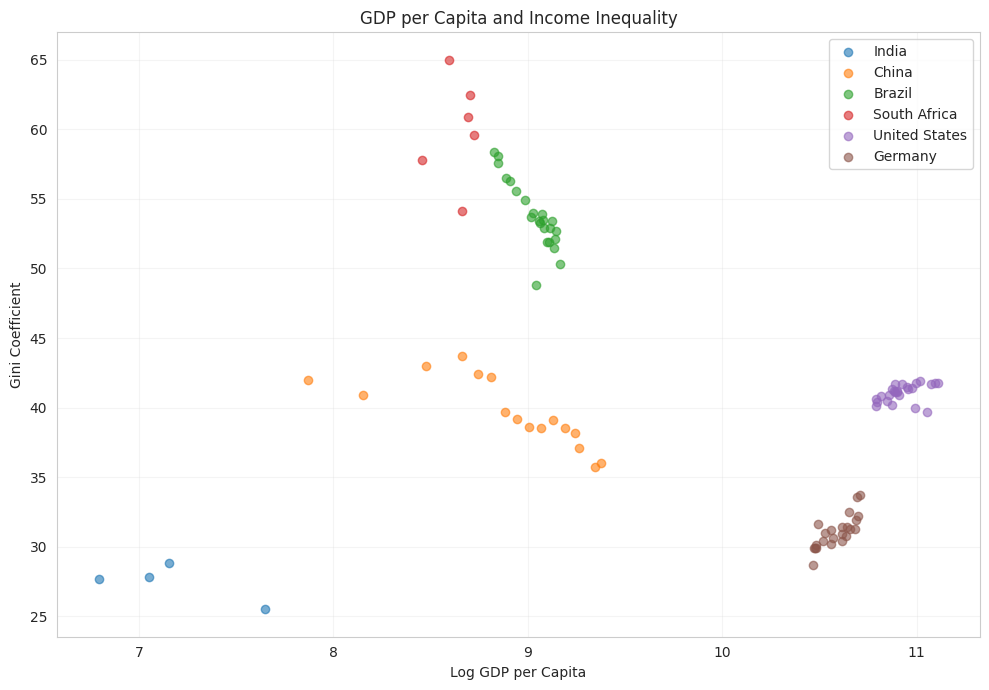

In [ ]:
plt.figure(figsize=(10, 7))

for country in COUNTRIES.values():

    temp = gini_df[
        gini_df["country"] == country
    ]

    plt.scatter(
        temp["log_gdp_per_capita"],
        temp["gini"],
        alpha=0.6,
        label=country
    )

plt.xlabel("Log GDP per Capita")
plt.ylabel("Gini Coefficient")
plt.title("GDP per Capita and Income Inequality")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "kuznets_scatter.png",
    dpi=300
)

plt.show()

In [ ]:
# ============================================================
# KUZNETS REGRESSION
# ============================================================

X = gini_df[
    [
        "log_gdp_per_capita",
        "log_gdp_per_capita_sq"
    ]
]

X = sm.add_constant(X)

y = gini_df["gini"]

kuznets_model = sm.OLS(
    y,
    X
).fit()

print(kuznets_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     25.60
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           1.33e-09
Time:                        17:26:23   Log-Likelihood:                -337.22
No. Observations:                  97   AIC:                             680.4
Df Residuals:                      94   BIC:                             688.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -251.62

In [ ]:
kuznets_coefficients = pd.DataFrame({
    "coefficient": kuznets_model.params,
    "p_value": kuznets_model.pvalues,
    "lower_95": kuznets_model.conf_int()[0],
    "upper_95": kuznets_model.conf_int()[1]
})

kuznets_coefficients

,coefficient,p_value,lower_95,upper_95
const,-251.626,0.000,-370.609,-132.643
log_gdp_per_capita,66.344,0.000,41.120,91.567
log_gdp_per_capita_sq,-3.669,0.000,-4.993,-2.345


In [ ]:
beta1 = kuznets_model.params["log_gdp_per_capita"]
beta2 = kuznets_model.params["log_gdp_per_capita_sq"]

if beta2 != 0:

    turning_point_log = -beta1 / (2 * beta2)

    turning_point_gdp = np.exp(
        turning_point_log
    )

    print(
        f"Estimated turning point: "
        f"{turning_point_gdp:,.2f}"
    )

else:

    print("No quadratic turning point.")

Estimated turning point: 8,440.47


In [ ]:
observed_min = gini_df["gdp_per_capita"].min()
observed_max = gini_df["gdp_per_capita"].max()

print("Observed minimum GDP per capita:",
      observed_min)

print("Observed maximum GDP per capita:",
      observed_max)

print("Estimated turning point:",
      turning_point_gdp)

Observed minimum GDP per capita: 892.596614580718
Observed maximum GDP per capita: 66856.5131698371
Estimated turning point: 8440.473679077482


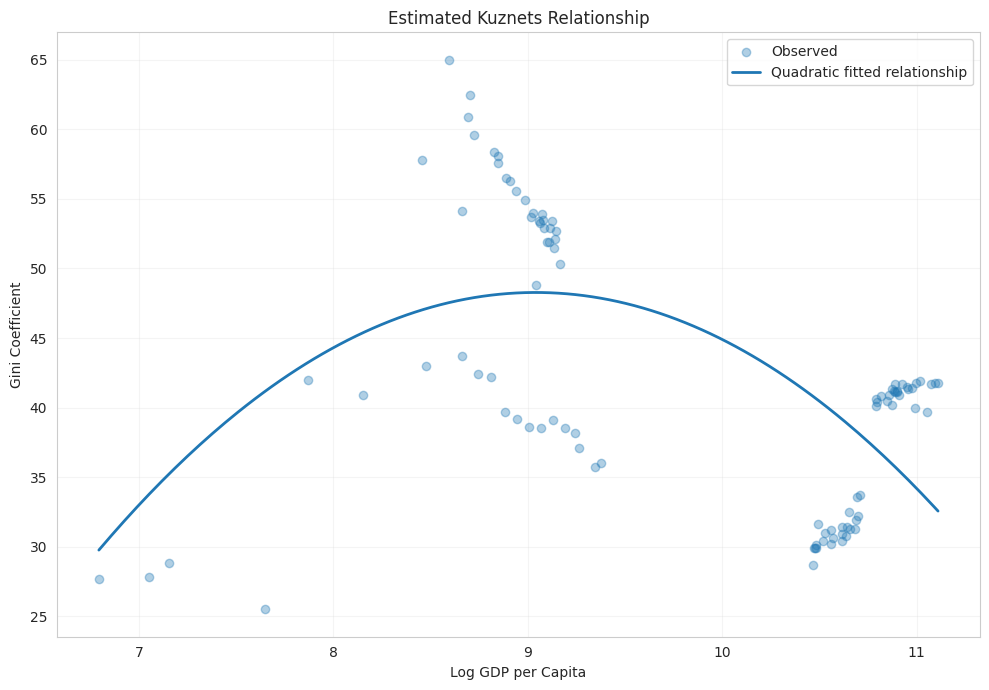

In [ ]:
x_grid = np.linspace(
    gini_df["log_gdp_per_capita"].min(),
    gini_df["log_gdp_per_capita"].max(),
    200
)

prediction_df = pd.DataFrame({
    "log_gdp_per_capita": x_grid,
    "log_gdp_per_capita_sq": x_grid ** 2
})

prediction_X = sm.add_constant(
    prediction_df
)

prediction_df["predicted_gini"] = (
    kuznets_model.predict(prediction_X)
)

plt.figure(figsize=(10, 7))

# Actual observations
plt.scatter(
    gini_df["log_gdp_per_capita"],
    gini_df["gini"],
    alpha=0.35,
    label="Observed"
)

# Fitted relationship
plt.plot(
    prediction_df["log_gdp_per_capita"],
    prediction_df["predicted_gini"],
    linewidth=2,
    label="Quadratic fitted relationship"
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Gini Coefficient")
plt.title("Estimated Kuznets Relationship")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "kuznets_fitted_curve.png",
    dpi=300
)

plt.show()

In [ ]:
poverty_summary = (
    poverty_df
    .groupby("country")
    .agg(
        average_poverty=("poverty_rate", "mean"),
        minimum_poverty=("poverty_rate", "min"),
        maximum_poverty=("poverty_rate", "max"),
        average_growth=("gdp_growth", "mean")
    )
    .reset_index()
)

poverty_summary

,country,average_poverty,minimum_poverty,maximum_poverty,average_growth
0,Brazil,8.609,2.800,17.500,2.070
1,China,10.844,0.000,47.800,7.564
2,Germany,0.161,0.000,0.700,1.270
3,India,28.350,5.300,46.400,7.159
4,South Africa,33.117,17.400,47.900,3.197
5,United States,1.032,0.300,1.400,2.219


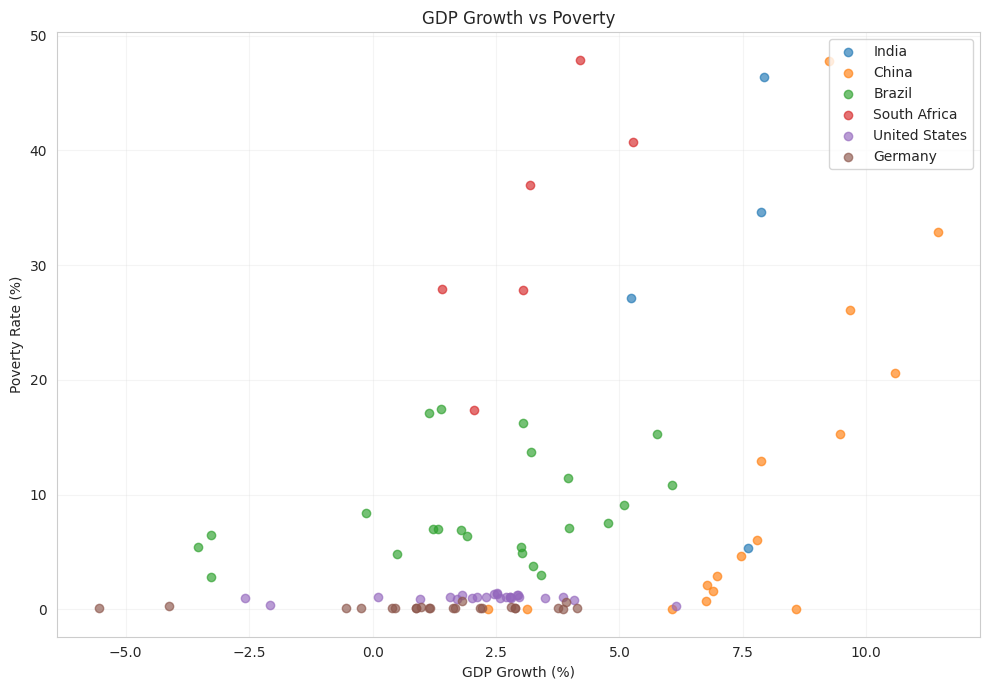

In [ ]:
plt.figure(figsize=(10, 7))

for country in COUNTRIES.values():

    temp = poverty_df[
        poverty_df["country"] == country
    ]

    plt.scatter(
        temp["gdp_growth"],
        temp["poverty_rate"],
        alpha=0.65,
        label=country
    )

plt.xlabel("GDP Growth (%)")
plt.ylabel("Poverty Rate (%)")
plt.title("GDP Growth vs Poverty")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "growth_vs_poverty.png",
    dpi=300
)

plt.show()

In [ ]:
X = poverty_df[
    [
        "gdp_growth",
        "log_gdp_per_capita"
    ]
]

X = sm.add_constant(X)

y = poverty_df["poverty_rate"]

poverty_model = sm.OLS(
    y,
    X
).fit()

print(poverty_model.summary())

                            OLS Regression Results                            
Dep. Variable:           poverty_rate   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.548
Method:                 Least Squares   F-statistic:                     59.26
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           2.24e-17
Time:                        17:28:26   Log-Likelihood:                -336.27
No. Observations:                  97   AIC:                             678.5
Df Residuals:                      94   BIC:                             686.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 80.2931      8

In [ ]:
benchmark = (
    full_df
    .groupby("country")
    .agg(
        avg_gini=("gini", "mean"),
        avg_growth=("gdp_growth", "mean"),
        avg_gdp_per_capita=("gdp_per_capita", "mean"),
        avg_poverty=("poverty_rate", "mean"),
        avg_population=("population", "mean")
    )
    .reset_index()
)

benchmark

,country,avg_gini,avg_growth,avg_gdp_per_capita,avg_poverty,avg_population
0,Brazil,53.809,2.070,"8,403.363",8.609,"196,781,923.174"
1,China,39.675,7.564,"7,789.955",10.844,"1,368,175,625.000"
2,Germany,31.083,1.270,"39,786.431",0.161,"82,154,636.609"
3,India,27.450,7.159,"1,356.880",28.350,"1,262,041,108.000"
4,South Africa,59.983,3.197,"5,668.748",33.117,"53,013,608.333"
5,United States,41.064,2.219,"55,875.308",1.032,"312,846,797.160"


In [ ]:
benchmark["gdp_per_capita_rank"] = (
    benchmark["avg_gdp_per_capita"]
    .rank(
        ascending=False,
        method="min"
    )
)

benchmark["inequality_rank"] = (
    benchmark["avg_gini"]
    .rank(
        ascending=True,
        method="min"
    )
)

benchmark["poverty_rank"] = (
    benchmark["avg_poverty"]
    .rank(
        ascending=True,
        method="min"
    )
)

benchmark = benchmark.sort_values(
    "gdp_per_capita_rank"
)

benchmark

,country,avg_gini,avg_growth,avg_gdp_per_capita,avg_poverty,avg_population,gdp_per_capita_rank,inequality_rank,poverty_rank
5,United States,41.064,2.219,"55,875.308",1.032,"312,846,797.160",1.000,4.000,2.000
2,Germany,31.083,1.270,"39,786.431",0.161,"82,154,636.609",2.000,2.000,1.000
0,Brazil,53.809,2.070,"8,403.363",8.609,"196,781,923.174",3.000,5.000,3.000
1,China,39.675,7.564,"7,789.955",10.844,"1,368,175,625.000",4.000,3.000,4.000
4,South Africa,59.983,3.197,"5,668.748",33.117,"53,013,608.333",5.000,6.000,6.000
3,India,27.450,7.159,"1,356.880",28.350,"1,262,041,108.000",6.000,1.000,5.000


In [ ]:
growth_median = benchmark["avg_growth"].median()
gini_median = benchmark["avg_gini"].median()

benchmark["growth_category"] = np.where(
    benchmark["avg_growth"] >= growth_median,
    "Higher Growth",
    "Lower Growth"
)

benchmark["inequality_category"] = np.where(
    benchmark["avg_gini"] <= gini_median,
    "Lower Inequality",
    "Higher Inequality"
)

benchmark[
    [
        "country",
        "growth_category",
        "inequality_category"
    ]
]

,country,growth_category,inequality_category
5,United States,Lower Growth,Higher Inequality
2,Germany,Lower Growth,Lower Inequality
0,Brazil,Lower Growth,Higher Inequality
1,China,Higher Growth,Lower Inequality
4,South Africa,Higher Growth,Higher Inequality
3,India,Higher Growth,Lower Inequality


In [ ]:
benchmark["development_profile"] = (
    benchmark["growth_category"]
    + " + "
    + benchmark["inequality_category"]
)

benchmark[
    [
        "country",
        "development_profile",
        "avg_growth",
        "avg_gini",
        "avg_poverty"
    ]
].sort_values("avg_growth", ascending=False)

,country,development_profile,avg_growth,avg_gini,avg_poverty
1,China,Higher Growth + Lower Inequality,7.564,39.675,10.844
3,India,Higher Growth + Lower Inequality,7.159,27.450,28.350
4,South Africa,Higher Growth + Higher Inequality,3.197,59.983,33.117
5,United States,Lower Growth + Higher Inequality,2.219,41.064,1.032
0,Brazil,Lower Growth + Higher Inequality,2.070,53.809,8.609
2,Germany,Lower Growth + Lower Inequality,1.270,31.083,0.161


In [ ]:
X = gini_df[["gdp_growth"]]

X = sm.add_constant(X)

y = gini_df["gini"]

growth_model = sm.OLS(
    y,
    X
).fit()

print(growth_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                   0.04673
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.829
Time:                        17:29:21   Log-Likelihood:                -358.29
No. Observations:                  97   AIC:                             720.6
Df Residuals:                      95   BIC:                             725.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.3115      1.401     30.201      0.0

In [ ]:
X = gini_df[
    [
        "gdp_growth",
        "log_gdp_per_capita"
    ]
]

X = sm.add_constant(X)

y = gini_df["gini"]

growth_development_model = sm.OLS(
    y,
    X
).fit()

print(growth_development_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.183
Method:                 Least Squares   F-statistic:                     11.76
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           2.77e-05
Time:                        17:29:31   Log-Likelihood:                -347.49
No. Observations:                  97   AIC:                             701.0
Df Residuals:                      94   BIC:                             708.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 89.7711      9

In [ ]:
# ============================================================
# COUNTRY FIXED EFFECTS
# ============================================================

country_dummies = pd.get_dummies(
    gini_df["country"],
    prefix="country",
    drop_first=True,
    dtype=int
)

X = pd.concat(
    [
        gini_df[
            [
                "gdp_growth",
                "log_gdp_per_capita",
                "log_gdp_per_capita_sq"
            ]
        ],
        country_dummies
    ],
    axis=1
)

X = sm.add_constant(X)

y = gini_df["gini"]

fixed_effects_model = sm.OLS(
    y,
    X
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": gini_df["country"]
    }
)

print(fixed_effects_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     3618.
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           9.26e-09
Time:                        17:29:43   Log-Likelihood:                -184.34
No. Observations:                  97   AIC:                             386.7
Df Residuals:                      88   BIC:                             409.8
Df Model:                           8                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   137.05

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [ ]:
year_dummies = pd.get_dummies(
    gini_df["year"],
    prefix="year",
    drop_first=True,
    dtype=int
)

X = pd.concat(
    [
        gini_df[
            [
                "gdp_growth",
                "log_gdp_per_capita",
                "log_gdp_per_capita_sq"
            ]
        ],
        country_dummies,
        year_dummies
    ],
    axis=1
)

X = sm.add_constant(X)

y = gini_df["gini"]

two_way_fe_model = sm.OLS(
    y,
    X
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": gini_df["country"]
    }
)

print(two_way_fe_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     12.27
Date:                Tue, 18 Aug 2026   Prob (F-statistic):            0.00780
Time:                        17:29:57   Log-Likelihood:                -171.70
No. Observations:                  97   AIC:                             409.4
Df Residuals:                      64   BIC:                             494.4
Df Model:                          32                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   177.89

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 32, but rank is 5
  warnings.warn('covariance of constraints does not have full '


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Growth only",
        "Growth + GDP per capita",
        "Kuznets",
        "Country FE",
        "Two-way FE"
    ],
    "R_squared": [
        growth_model.rsquared,
        growth_development_model.rsquared,
        kuznets_model.rsquared,
        fixed_effects_model.rsquared,
        two_way_fe_model.rsquared
    ],
    "Observations": [
        int(growth_model.nobs),
        int(growth_development_model.nobs),
        int(kuznets_model.nobs),
        int(fixed_effects_model.nobs),
        int(two_way_fe_model.nobs)
    ]
})

model_comparison

,Model,R_squared,Observations
0,Growth only,0.000,97
1,Growth + GDP per capita,0.200,97
2,Kuznets,0.353,97
3,Country FE,0.972,97
4,Two-way FE,0.979,97


In [ ]:
key_results = pd.DataFrame({
    "Model": [
        "Growth only",
        "Growth + GDP per capita",
        "Kuznets",
        "Country FE",
        "Two-way FE"
    ],

    "Growth coefficient": [
        growth_model.params.get("gdp_growth", np.nan),
        growth_development_model.params.get("gdp_growth", np.nan),
        np.nan,
        fixed_effects_model.params.get("gdp_growth", np.nan),
        two_way_fe_model.params.get("gdp_growth", np.nan)
    ],

    "Growth p-value": [
        growth_model.pvalues.get("gdp_growth", np.nan),
        growth_development_model.pvalues.get("gdp_growth", np.nan),
        np.nan,
        fixed_effects_model.pvalues.get("gdp_growth", np.nan),
        two_way_fe_model.pvalues.get("gdp_growth", np.nan)
    ]
})

key_results

,Model,Growth coefficient,Growth p-value
0,Growth only,-0.068,0.829
1,Growth + GDP per capita,-0.836,0.012
2,Kuznets,NaN,NaN
3,Country FE,0.178,0.022
4,Two-way FE,0.257,0.023


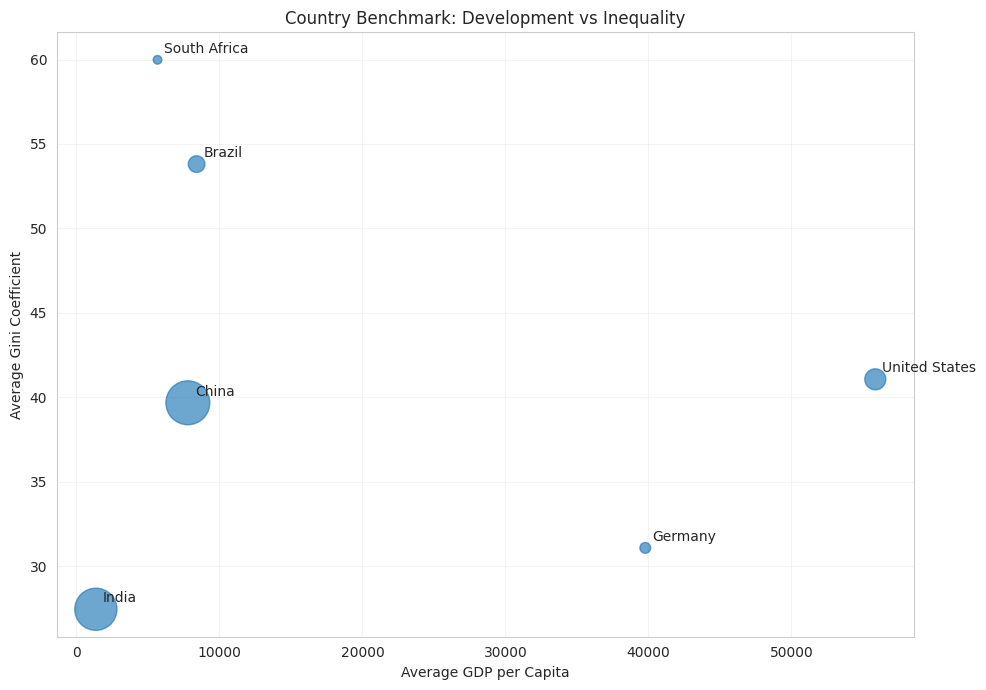

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    benchmark["avg_gdp_per_capita"],
    benchmark["avg_gini"],
    s=benchmark["avg_population"] / benchmark["avg_population"].max() * 1000,
    alpha=0.65
)

for _, row in benchmark.iterrows():

    plt.annotate(
        row["country"],
        (
            row["avg_gdp_per_capita"],
            row["avg_gini"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average GDP per Capita")
plt.ylabel("Average Gini Coefficient")
plt.title("Country Benchmark: Development vs Inequality")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "country_benchmark.png",
    dpi=300
)

plt.show()

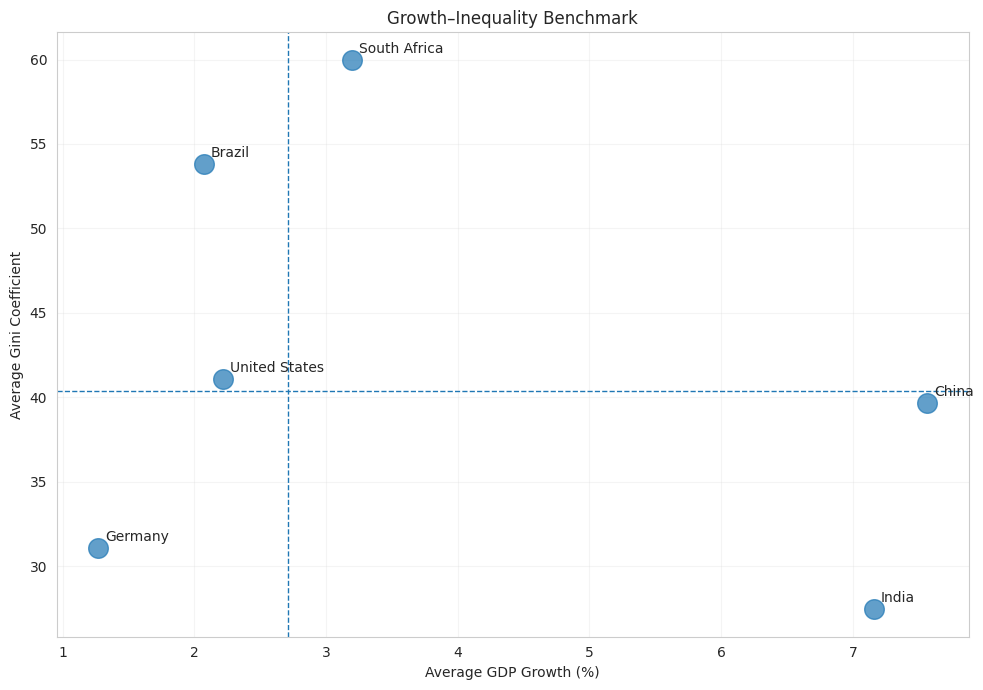

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    benchmark["avg_growth"],
    benchmark["avg_gini"],
    s=200,
    alpha=0.7
)

for _, row in benchmark.iterrows():

    plt.annotate(
        row["country"],
        (
            row["avg_growth"],
            row["avg_gini"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.axvline(
    benchmark["avg_growth"].median(),
    linestyle="--",
    linewidth=1
)

plt.axhline(
    benchmark["avg_gini"].median(),
    linestyle="--",
    linewidth=1
)

plt.xlabel("Average GDP Growth (%)")
plt.ylabel("Average Gini Coefficient")
plt.title("Growth–Inequality Benchmark")
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "growth_inequality_benchmark.png",
    dpi=300
)

plt.show()

In [ ]:
final_results = benchmark[
    [
        "country",
        "avg_gdp_per_capita",
        "avg_growth",
        "avg_gini",
        "avg_poverty",
        "gdp_per_capita_rank",
        "inequality_rank",
        "poverty_rank"
    ]
].copy()

final_results = final_results.sort_values(
    "gdp_per_capita_rank"
)

final_results

,country,avg_gdp_per_capita,avg_growth,avg_gini,avg_poverty,gdp_per_capita_rank,inequality_rank,poverty_rank
5,United States,"55,875.308",2.219,41.064,1.032,1.000,4.000,2.000
2,Germany,"39,786.431",1.270,31.083,0.161,2.000,2.000,1.000
0,Brazil,"8,403.363",2.070,53.809,8.609,3.000,5.000,3.000
1,China,"7,789.955",7.564,39.675,10.844,4.000,3.000,4.000
4,South Africa,"5,668.748",3.197,59.983,33.117,5.000,6.000,6.000
3,India,"1,356.880",7.159,27.450,28.350,6.000,1.000,5.000


In [ ]:
data.to_csv(
    OUTPUT_DIR / "world_bank_raw_merged.csv",
    index=False
)

gini_df.to_csv(
    OUTPUT_DIR / "gini_analysis_dataset.csv",
    index=False
)

poverty_df.to_csv(
    OUTPUT_DIR / "poverty_analysis_dataset.csv",
    index=False
)

full_df.to_csv(
    OUTPUT_DIR / "full_analysis_dataset.csv",
    index=False
)

benchmark.to_csv(
    OUTPUT_DIR / "country_benchmark.csv",
    index=False
)

print("Datasets saved.")

Datasets saved.


In [ ]:
with open(
    OUTPUT_DIR / "regression_results.txt",
    "w"
) as f:

    f.write("GROWTH MODEL\n")
    f.write(str(growth_model.summary()))

    f.write("\n\nKUznETS MODEL\n")
    f.write(str(kuznets_model.summary()))

    f.write("\n\nCOUNTRY FIXED EFFECTS MODEL\n")
    f.write(str(fixed_effects_model.summary()))

    f.write("\n\nTWO-WAY FIXED EFFECTS MODEL\n")
    f.write(str(two_way_fe_model.summary()))

print("Regression results saved.")

Regression results saved.


In [ ]:
key_findings_table = pd.DataFrame({
    "Analysis": [
        "Average inequality",
        "Average GDP growth",
        "Average GDP per capita",
        "Average poverty",
        "Growth–inequality correlation"
    ],

    "Measure": [
        "Mean Gini",
        "Mean GDP growth",
        "Mean GDP per capita",
        "Mean poverty rate",
        "Correlation"
    ]
})

key_findings_table

,Analysis,Measure
0,Average inequality,Mean Gini
1,Average GDP growth,Mean GDP growth
2,Average GDP per capita,Mean GDP per capita
3,Average poverty,Mean poverty rate
4,Growth–inequality correlation,Correlation


In [ ]:
excel_path = OUTPUT_DIR / "income_inequality_analysis.xlsx"

with pd.ExcelWriter(excel_path) as writer:

    data.to_excel(
        writer,
        sheet_name="Raw Data",
        index=False
    )

    gini_df.to_excel(
        writer,
        sheet_name="Gini Analysis",
        index=False
    )

    poverty_df.to_excel(
        writer,
        sheet_name="Poverty Analysis",
        index=False
    )

    benchmark.to_excel(
        writer,
        sheet_name="Benchmark",
        index=False
    )

    model_comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

print(f"Saved to: {excel_path}")

Saved to: outputs/income_inequality_analysis.xlsx


In [ ]:
from google.colab import files

files.download(
    "outputs/income_inequality_analysis.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>